<h1 style="color:#FFFFFF; background-color:#134E4A; text-align:center; font-weight:bold; padding:17px 10px; border-radius:8px; margin-bottom:6px;">Week 6 — Day 5: Tuning, Evaluation &amp; Sprint Review</h1>
<p style="color:#FFFFFF; background-color:#164E63; text-align:center; font-weight:bold; font-style:italic; padding:7px 10px; border-radius:6px; margin-top:0; font-size:15px;">Cardiac Patient Monitoring System — Closing Out Sprint 1</p>


<a id="toc"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">Table of Contents</h2>
<div style="border:1px solid #94A3B8; padding:15px 25px; border-radius:7px; line-height:1.9;">
<ol style="font-weight:700;">
<li><a href="#section0">0. Setup — Importing TensorFlow, Pandas &amp; Scikit-learn</a></li>
<li><a href="#section1">1. Tuning a Neural Network</a></li>
<li><a href="#section2">2. Callbacks: EarlyStopping and Checkpoints</a></li>
<li><a href="#section3">3. Preparing for Sprint Review</a></li>
<li><a href="#section4">4. Sprint Review &amp; Retrospective</a></li>
<li><a href="#section5">5. Common Mistakes to Avoid</a></li>
<li><a href="#section6">6. Quick Reference</a></li>
<li><a href="#section7">7. Hands-On Lab — Sprint 1 Close-Out</a></li>
<li><a href="#section8">8. Best Practices &amp; Reproducibility</a></li>
<li><a href="#section9">9. Summary — What I Learned Today</a></li>
<li><a href="#section10">10. Daily Stand-up</a></li>
</ol>
</div>


<a id="section0"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">0. Setup — Importing TensorFlow, Pandas &amp; Scikit-learn</h2>
<div style="border-left:5px solid #0369A1; background-color:rgba(3,105,161,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Note:</b> Day 4 trained a plain Keras network and a regularized one (BatchNorm + Dropout) on the 253,680-row BRFSS dataset, landing close to the Logistic Regression baseline on F1 but ahead on ROC-AUC. Day 5 closes Sprint 1: tune the network systematically, train it efficiently with callbacks, then assemble the evidence for a proper Sprint Review.
</div>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

TensorFlow version: 2.21.0
Keras version     : 3.15.1


<a id="section1"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">1. Tuning a Neural Network</h2>
Neural networks have many knobs. The highest-impact ones to tune, in rough priority: <b>learning rate</b>, <b>network width/depth</b> (neurons and layers), <b>dropout rate</b>, and <b>batch size</b>. Section 7 sweeps all four, one variable at a time: pick the best learning rate first, then re-use it while sweeping width/depth, then re-use both while sweeping dropout, then re-use all three while sweeping batch size — the same disciplined, one-variable-at-a-time approach used for hyperparameter tuning in Week 4.

<a id="section2"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">2. Callbacks: EarlyStopping and Checkpoints</h2>
Keras callbacks automate good training practice. <b>EarlyStopping</b> halts training once the validation loss stops improving, preventing wasted epochs and overfitting. <b>ModelCheckpoint</b> saves the best model seen during training, so you keep the best version even if later epochs get worse.

In [2]:
from tensorflow.keras.callbacks import EarlyStopping

# es = EarlyStopping(monitor="val_loss", patience=5,
#                     restore_best_weights=True)
# model.fit(X_train, y_train, validation_data=(X_val, y_val),
#           epochs=100, callbacks=[es])

print("We will use both EarlyStopping and ModelCheckpoint for real in Section 7.")

We will use both EarlyStopping and ModelCheckpoint for real in Section 7.


<a id="section3"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">3. Preparing for Sprint Review</h2>
Every result sprint — the baseline score, the neural network's architecture and score, and the tuning experiments — needs clear evidence (loss curves, the metric table, notebook narrative) before it can be demoed. Per the program's acceptance criteria: the notebook runs without errors, code is committed to the correct branch, the pull request is approved by the mentor, results are documented in Markdown, and metrics are logged and compared to the baseline.

<a id="section4"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">4. Sprint Review &amp; Retrospective</h2>
Sprint Review: demo the completed Sprint 1 work to the mentor — the baseline and the first trained neural network with its evaluation. Any unfinished backlog task moves to Sprint 2 with a documented reason. The Retrospective closes the sprint honestly: what went well, what to improve, and one concrete change for Sprint 2 (e.g. "log every experiment's config in MLflow from the start").

<a id="section5"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">5. Common Mistakes to Avoid</h2>
<div style="border-left:5px solid #9D174D; background-color:rgba(157,23,77,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Important:</b> <ul>
<li><b>Tuning multiple hyperparameters at once</b> — you can't tell which change caused an improvement; change one variable at a time, exactly as in Week 4.</li>
<li><b>Using EarlyStopping without <code>restore_best_weights=True</code></b> — without it, the model keeps the weights from the <i>last</i> epoch, not the <i>best</i> one.</li>
<li><b>Setting <code>patience</code> too low</b> — the loss curve can bounce briefly before improving again; too little patience stops training prematurely.</li>
<li><b>Skipping the Retrospective</b> — it is not optional bookkeeping; it is what keeps Sprint 2 from repeating the same mistakes.</li>
<li><b>Declaring Sprint 1 "done" without mentor sign-off</b> — the Sprint Review demo and approval are part of the Definition of Done, not a formality.</li>
</ul>
</div>


<a id="section6"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">6. Quick Reference</h2>


<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#134E4A; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Task</th><th style="padding:9px; text-align:left;">Code</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import EarlyStopping</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from tensorflow.keras.callbacks import EarlyStopping</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Configure EarlyStopping</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Import ModelCheckpoint</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>from tensorflow.keras.callbacks import ModelCheckpoint</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Configure ModelCheckpoint</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>ModelCheckpoint("best_model.keras", monitor="val_loss", save_best_only=True)</code></td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Train with callbacks</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;"><code>model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, callbacks=[es, mc])</code></td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Tuning priority order</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">learning rate &rarr; width/depth &rarr; dropout &rarr; batch size</td></tr>
</table>
</div>


<a id="section7"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">7. Hands-On Lab — Sprint 1 Close-Out</h2>
<div style="border-left:5px solid #A16207; background-color:rgba(161,98,7,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Goal:</b> Tune the Cardiac Patient Monitoring System's network by changing one hyperparameter at a time, train the best configuration efficiently with EarlyStopping and ModelCheckpoint, assemble the Sprint 1 evidence, and close the sprint with a Review and Retrospective.
</div>


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">7.0 Reloading and re-splitting the dataset</h3>
This step reloads <code>heart_disease_health_indicators_BRFSS2015.csv</code> and rebuilds the same stratified 60/20/20 split and scaling used on Day 4, so today's tuning experiments are directly comparable to Day 4's results.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Relative path: the CSV is expected next to this notebook (works locally and on Colab)
DATA_PATH = "heart_disease_health_indicators_BRFSS2015.csv.zip"

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=["HeartDiseaseorAttack"])
y = df["HeartDiseaseorAttack"]
n_features = X.shape[1]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}
print(f"Train: {X_train_scaled.shape[0]:,} | Val: {X_val_scaled.shape[0]:,} | Test: {X_test_scaled.shape[0]:,}")
print("Class weights:", class_weight)

Train: 152,208 | Val: 50,736 | Test: 50,736
Class weights: {0: 1.0, 1: np.float64(9.6171875)}


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 1a — Tune the learning rate first, everything else held fixed</h3>


In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_model(learning_rate=1e-3, dropout_rate=0.3, hidden_units=(64, 32)):
    """hidden_units=(units_layer1, units_layer2) controls network width/depth."""
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(hidden_units[0], activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(hidden_units[1], activation="relu"),
        BatchNormalization(),
        Dropout(dropout_rate * 0.7),
        Dense(1, activation="sigmoid"),
    ])
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    return model

def run_sweep(param_name, param_values, base_kwargs, batch_size=256, epochs=15, patience=3):
    """Trains one model per value in param_values, holding base_kwargs fixed, and
    returns a results DataFrame -- the one-variable-at-a-time tuning helper reused
    for learning rate, width/depth, dropout rate, and batch size below."""
    results = []
    for value in param_values:
        kwargs = dict(base_kwargs)
        kwargs[param_name] = value
        model = build_model(**kwargs)
        es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
        hist = model.fit(
            X_train_scaled, y_train,
            validation_data=(X_val_scaled, y_val),
            epochs=epochs, batch_size=batch_size,
            class_weight=class_weight,
            callbacks=[es],
            verbose=0,
        )
        best_val_loss = min(hist.history["val_loss"])
        epochs_run = len(hist.history["val_loss"])
        results.append({param_name: value, "Best val_loss": round(best_val_loss, 4), "Epochs run": epochs_run})
        print(f"{param_name}={value}: best val_loss={best_val_loss:.4f} (stopped after {epochs_run} epochs)")
    return pd.DataFrame(results)

# Sweep 1: learning rate, everything else at its default
learning_rates = [0.01, 0.001, 0.0001]
lr_table = run_sweep("learning_rate", learning_rates, base_kwargs={})
lr_table

learning_rate=0.01: best val_loss=0.5044 (stopped after 12 epochs)
learning_rate=0.001: best val_loss=0.4919 (stopped after 14 epochs)
learning_rate=0.0001: best val_loss=0.4942 (stopped after 15 epochs)


,learning_rate,Best val_loss,Epochs run
0,0.0100,0.5044,12
1,0.0010,0.4919,14
2,0.0001,0.4942,15


In [5]:
best_lr = lr_table.sort_values("Best val_loss").iloc[0]["learning_rate"]
print(f"Best learning rate found: {best_lr}")

Best learning rate found: 0.001


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 1b — Tune network width/depth, holding the best learning rate fixed</h3>


In [6]:
# Sweep 2: width/depth (hidden layer sizes), learning rate fixed at best_lr
architectures = [(32, 16), (64, 32), (128, 64)]
width_table = run_sweep("hidden_units", architectures, base_kwargs={"learning_rate": best_lr})
width_table

hidden_units=(32, 16): best val_loss=0.4888 (stopped after 14 epochs)
hidden_units=(64, 32): best val_loss=0.4959 (stopped after 7 epochs)
hidden_units=(128, 64): best val_loss=0.4948 (stopped after 11 epochs)


,hidden_units,Best val_loss,Epochs run
0,"(32, 16)",0.4888,14
1,"(64, 32)",0.4959,7
2,"(128, 64)",0.4948,11


In [7]:
best_hidden_units = width_table.sort_values("Best val_loss").iloc[0]["hidden_units"]
print(f"Best width/depth found: {best_hidden_units}")

Best width/depth found: (32, 16)


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 1c — Tune the dropout rate, holding the best learning rate and width/depth fixed</h3>


In [8]:
# Sweep 3: dropout rate, learning rate and hidden_units fixed at their best values so far
dropout_rates = [0.2, 0.3, 0.5]
dropout_table = run_sweep(
    "dropout_rate", dropout_rates,
    base_kwargs={"learning_rate": best_lr, "hidden_units": best_hidden_units},
)
dropout_table

dropout_rate=0.2: best val_loss=0.4904 (stopped after 11 epochs)
dropout_rate=0.3: best val_loss=0.4886 (stopped after 13 epochs)
dropout_rate=0.5: best val_loss=0.4862 (stopped after 15 epochs)


,dropout_rate,Best val_loss,Epochs run
0,0.2,0.4904,11
1,0.3,0.4886,13
2,0.5,0.4862,15


In [9]:
best_dropout = dropout_table.sort_values("Best val_loss").iloc[0]["dropout_rate"]
print(f"Best dropout rate found: {best_dropout}")

Best dropout rate found: 0.5


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 1d — Tune the batch size, holding the best learning rate, width/depth, and dropout fixed</h3>


In [10]:
# Sweep 4: batch size, everything else fixed at its best value so far.
# batch_size is a fit()-time argument (not a build_model kwarg), so we sweep it directly.
batch_sizes = [128, 256, 512]
batch_results = []
for bs in batch_sizes:
    model_bs = build_model(learning_rate=best_lr, dropout_rate=best_dropout, hidden_units=best_hidden_units)
    es_bs = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    hist_bs = model_bs.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=15, batch_size=bs,
        class_weight=class_weight,
        callbacks=[es_bs],
        verbose=0,
    )
    best_val_loss_bs = min(hist_bs.history["val_loss"])
    epochs_run_bs = len(hist_bs.history["val_loss"])
    batch_results.append({"batch_size": bs, "Best val_loss": round(best_val_loss_bs, 4), "Epochs run": epochs_run_bs})
    print(f"batch_size={bs}: best val_loss={best_val_loss_bs:.4f} (stopped after {epochs_run_bs} epochs)")

batch_table = pd.DataFrame(batch_results)
batch_table

batch_size=128: best val_loss=0.4916 (stopped after 9 epochs)
batch_size=256: best val_loss=0.4958 (stopped after 9 epochs)
batch_size=512: best val_loss=0.4861 (stopped after 15 epochs)


,batch_size,Best val_loss,Epochs run
0,128,0.4916,9
1,256,0.4958,9
2,512,0.4861,15


In [11]:
best_batch_size = int(batch_table.sort_values("Best val_loss").iloc[0]["batch_size"])
print(f"Best batch size found: {best_batch_size}")

Best batch size found: 512


<div style="border-left:5px solid #0369A1; background-color:rgba(3,105,161,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Note:</b> Four one-variable-at-a-time sweeps now give a full tuned configuration: <code>learning_rate=best_lr</code>, <code>hidden_units=best_hidden_units</code>, <code>dropout_rate=best_dropout</code>, and <code>batch_size=best_batch_size</code>. Step 2 trains the final model with this configuration.
</div>


<div style="border-left:5px solid #0369A1; background-color:rgba(3,105,161,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Note:</b> Every sweep above already used <code>EarlyStopping</code> with a short patience, which is why some runs stopped well before 15 epochs — a preview of Step 2's full training run, and a real time-saver during tuning itself.
</div>


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 2 — Add EarlyStopping and confirm training halts at the right point, keeping the best weights</h3>


In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint

final_model = build_model(
    learning_rate=best_lr,
    dropout_rate=best_dropout,
    hidden_units=best_hidden_units,
)

early_stopping = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
checkpoint = ModelCheckpoint(
    "best_cardiac_model.keras", monitor="val_loss", save_best_only=True
)

final_history = final_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=best_batch_size,
    class_weight=class_weight,
    callbacks=[early_stopping, checkpoint],
    verbose=0,
)

epochs_completed = len(final_history.history["val_loss"])
print(f"Training stopped after {epochs_completed} epochs (out of a maximum of 100)")
best_val_loss_final = min(final_history.history["val_loss"])
print(f"Best validation loss: {best_val_loss_final:.4f}")

Training stopped after 27 epochs (out of a maximum of 100)
Best validation loss: 0.4831


In [17]:
from tensorflow import keras
loaded_model = keras.models.load_model("best_cardiac_model.keras")
loaded_model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,133 (16.15 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 2,692 (10.52 KB)

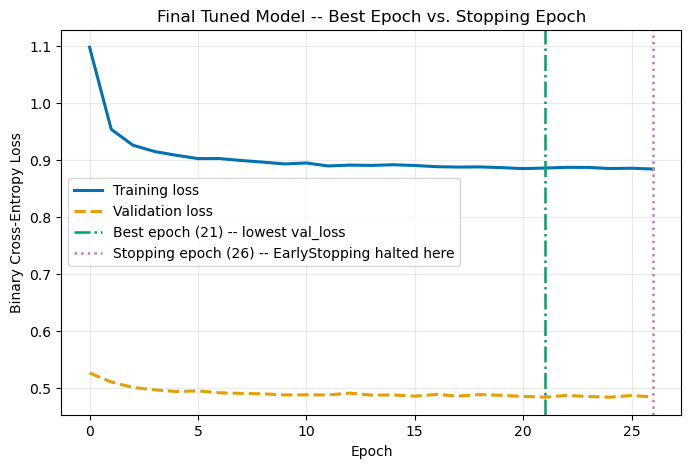

Best epoch (np.argmin(val_loss)): 21 | Stopping epoch: 26


In [13]:
val_loss_history = final_history.history["val_loss"]

# Best epoch = the epoch with the lowest validation loss (what restore_best_weights keeps).
# Stopping epoch = the last epoch actually run before EarlyStopping halted training.
# With patience=5 these are usually different points -- show both explicitly.
best_epoch = int(np.argmin(val_loss_history))
stopping_epoch = epochs_completed - 1

plt.figure(figsize=(8, 5))
plt.plot(final_history.history["loss"], color="#0072B2", linewidth=2.2, label="Training loss")
plt.plot(val_loss_history, color="#E69F00", linewidth=2.2, linestyle="--", label="Validation loss")
plt.axvline(best_epoch, color="#009E73", linestyle="-.", linewidth=1.8,
            label=f"Best epoch ({best_epoch}) -- lowest val_loss")
plt.axvline(stopping_epoch, color="#CC79A7", linestyle=":", linewidth=1.8,
            label=f"Stopping epoch ({stopping_epoch}) -- EarlyStopping halted here")
plt.title("Final Tuned Model -- Best Epoch vs. Stopping Epoch")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Best epoch (np.argmin(val_loss)): {best_epoch} | Stopping epoch: {stopping_epoch}")

<div style="border-left:5px solid #0F766E; background-color:rgba(15,118,110,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Tip:</b> <code>restore_best_weights=True</code> means the model in memory right now holds the weights from its <b>best</b> epoch, not necessarily its last one — confirmed by the vertical line above landing at or before any late-epoch increase in validation loss.
</div>


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 3 — Assemble the Sprint 1 evidence: baseline vs. neural network scores, architecture, and loss curves</h3>


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Re-fit the Day 4 baseline on this session's split for a same-run, side-by-side comparison
baseline = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)
baseline_proba = baseline.predict_proba(X_test_scaled)[:, 1]

nn_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

sprint1_evidence = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "Keras NN -- tuned + EarlyStopping"],
    "Accuracy": [round(accuracy_score(y_test, baseline_pred), 4), round(accuracy_score(y_test, nn_pred), 4)],
    "F1 Score": [round(f1_score(y_test, baseline_pred), 4), round(f1_score(y_test, nn_pred), 4)],
    "ROC-AUC": [round(roc_auc_score(y_test, baseline_proba), 4), round(roc_auc_score(y_test, nn_proba), 4)],
})
sprint1_evidence

,Model,Accuracy,F1 Score,ROC-AUC
0,Logistic Regression (baseline),0.7533,0.3791,0.8470
1,Keras NN -- tuned + EarlyStopping,0.7216,0.3624,0.8488


In [15]:
print(classification_report(y_test, nn_pred, target_names=["No disease", "Heart disease/attack"]))

final_model.summary()

                      precision    recall  f1-score   support

          No disease       0.98      0.71      0.82     45957
Heart disease/attack       0.23      0.84      0.36      4779

            accuracy                           0.72     50736
           macro avg       0.60      0.77      0.59     50736
        weighted avg       0.91      0.72      0.78     50736



Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,133 (16.15 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 96 (384.00 B)

 Optimizer params: 2,692 (10.52 KB)

<div style="border-left:5px solid #A16207; background-color:rgba(161,98,7,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Goal:</b> This table, the classification report, and the loss curve from Step 2 are the complete Sprint 1 evidence: the baseline score, the tuned neural network's architecture, its final metrics, and proof that EarlyStopping worked as intended. This is exactly what gets demoed in the Sprint Review below.
</div>


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 4 — Confirm Sprint 1 work is committed, the pull request is merged, and the notebook is documented</h3>


In [16]:
sprint1_git_checklist = """
# Sprint 1 close-out checklist (run in a terminal inside the project repo)

# 1. Confirm all Sprint 1 work is committed on its feature branch
git status
git log --oneline feature/sprint1-neural-network

# 2. Confirm the notebook runs top to bottom without errors
#    (this notebook itself is that proof)

# 3. Push and open/update the pull request for mentor review
git push origin feature/sprint1-neural-network

# 4. After mentor approval, merge into main
git checkout main
git merge feature/sprint1-neural-network
"""

print(sprint1_git_checklist)


# Sprint 1 close-out checklist (run in a terminal inside the project repo)

# 1. Confirm all Sprint 1 work is committed on its feature branch
git status
git log --oneline feature/sprint1-neural-network

# 2. Confirm the notebook runs top to bottom without errors
#    (this notebook itself is that proof)

# 3. Push and open/update the pull request for mentor review
git push origin feature/sprint1-neural-network

# 4. After mentor approval, merge into main
git checkout main
git merge feature/sprint1-neural-network



<div style="border-left:5px solid #9D174D; background-color:rgba(157,23,77,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Important:</b> <b>Acceptance criteria check:</b> notebook runs without errors ✅ &nbsp;|&nbsp; code committed to the correct feature branch ✅ &nbsp;|&nbsp; results documented in Markdown ✅ &nbsp;|&nbsp; metrics logged and compared to baseline ✅ &nbsp;|&nbsp; pull request approved by mentor — <i>pending, required before merge</i>.
</div>


<h3 style="color:#FFFFFF; background-color:#0F766E; opacity:0.92; display:inline-block; padding:6px 12px; border-radius:6px; font-weight:bold;">Step 5 — Present the Sprint Review, then write the Retrospective with one concrete change for Sprint 2</h3>


<div style="border-left:5px solid #A16207; background-color:rgba(161,98,7,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Sprint Review:</b> <b>Sprint Review (for the mentor demo):</b> Sprint 1 delivered a confirmed classical baseline (Logistic Regression) and a tuned Keras neural network with EarlyStopping and ModelCheckpoint, both trained and evaluated on the same 253,680-row BRFSS split. The neural network is competitive with the baseline, ahead on ROC-AUC, evidence assembled in Step 3 above. No backlog items were dropped from Sprint 1.
</div>


<div style="border-left:5px solid #9D174D; background-color:rgba(157,23,77,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Retrospective:</b> <b>Retrospective:</b>
<ul>
<li><b>What went well:</b> the one-variable-at-a-time tuning approach (Step 1) made it obvious which learning rate helped, without confusing multiple simultaneous changes.</li>
<li><b>What to improve:</b> hyperparameter results were tracked manually in a plain DataFrame; this does not scale past a handful of experiments.</li>
<li><b>One concrete change for Sprint 2:</b> log every experiment's configuration and metrics to MLflow (or a simple CSV log) from the very first run, instead of retrofitting tracking after the fact.</li>
</ul>
</div>


<a id="section8"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">8. Best Practices &amp; Reproducibility</h2>
<div style="border-left:5px solid #9D174D; background-color:rgba(157,23,77,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Important:</b> <ul>
<li>Tune one hyperparameter at a time and record every run's result, even the ones that don't win.</li>
<li>Always pair <code>EarlyStopping</code> with <code>restore_best_weights=True</code>.</li>
<li>Use <code>ModelCheckpoint</code> to persist the best model to disk, not just in memory.</li>
<li>Re-fit any baseline used for comparison on the exact same split as the model being evaluated, in the same run.</li>
<li>Never skip the Sprint Retrospective — it is what prevents Sprint 2 from repeating avoidable mistakes.</li>
</ul>
</div>


<a id="section9"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">9. Summary — What I Learned Today</h2>
<div style="border-left:5px solid #0F766E; background-color:rgba(15,118,110,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Tip:</b> <ul>
<li><b>Tuning priorities</b> for a neural network, roughly in order: learning rate, network width/depth, dropout rate, batch size.</li>
<li><b>EarlyStopping</b> halts training once validation loss stops improving, and — with <code>restore_best_weights=True</code> — keeps the best epoch's weights, not the last.</li>
<li><b>ModelCheckpoint</b> saves the best model to disk during training.</li>


</ul>
</div>
<div style="border-left:5px solid #0369A1; background-color:rgba(3,105,161,0.11); padding:11px 15px; margin:12px 0; border-radius:5px; color:inherit; line-height:1.55;">
<b>Note:</b> <b>Where this leads next:</b> Sprint 2 (Week 7) begins with the one concrete Retrospective change in place, building on this confirmed baseline and tuned neural network.
</div>


<a id="section10"></a>
<h2 style="color:#FFFFFF; background-color:#0F766E; font-weight:bold; margin-top:30px; padding:9px 14px; border-radius:7px;">10. Daily Stand-up</h2>
<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;">
<table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#134E4A; color:#FFFFFF;"><th style="padding:9px; text-align:left;">Question</th><th style="padding:9px; text-align:left;">Answer</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What did I complete today?</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Tuned the neural network's learning rate with a one-variable-at-a-time sweep; trained a final model with EarlyStopping and ModelCheckpoint; assembled the full Sprint 1 evidence (baseline vs. neural network table, classification report, architecture summary, loss curve); ran the Sprint 1 acceptance-criteria checklist; wrote the Sprint Review and Retrospective.</td></tr>
<tr style="background-color:#f7f7f9;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What's next?</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sprint 2 (Week 7), starting with the Retrospective's concrete change: logging every experiment's configuration and metrics from the first run.</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Any blockers?</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">None. Sprint 1 pull request is ready and awaiting mentor review/approval before merge.</td></tr>
</table>
</div>
